In [1]:
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
from sklearn.metrics import root_mean_squared_error
from sklearn.metrics import mean_absolute_error

In [2]:
df = pd.read_csv("Drugs_Performance.csv")

In [3]:
df.dtypes

Age             int64
Drugs_Perf    float64
dtype: object

In [4]:
df.corr()

,Age,Drugs_Perf
Age,1.000000,0.969656
Drugs_Perf,0.969656,1.000000


In [5]:
X = df[['Age']]
y = df['Drugs_Perf']

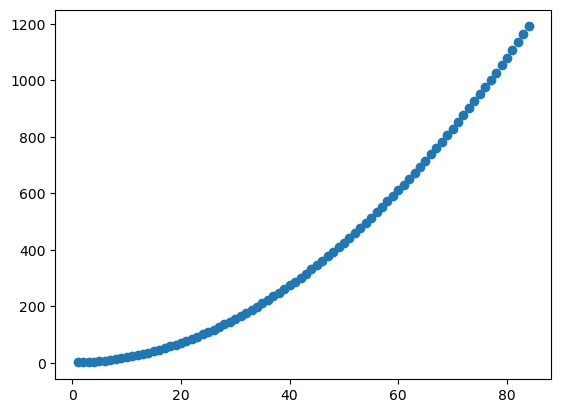

In [6]:
plt.scatter(df[['Age']],df['Drugs_Perf'])

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 84 entries, 0 to 83
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Age         84 non-null     int64  
 1   Drugs_Perf  84 non-null     float64
dtypes: float64(1), int64(1)
memory usage: 1.4 KB


In [8]:
Xtrain,Xtest,ytrain,ytest=train_test_split(X,y,test_size=0.2,random_state=0)

In [9]:
from sklearn.preprocessing import PolynomialFeatures
poly = PolynomialFeatures(degree=1)

In [10]:
update_Xtrain=poly.fit_transform(Xtrain)
update_Xtest=poly.transform(Xtest)

In [11]:
Xtrain

,Age
73,74
48,49
74,75
83,84
61,62
...,...
80,81
67,68
64,65
47,48


In [12]:
model = LinearRegression()
model.fit(update_Xtrain,ytrain)

LinearRegression()

In [13]:
ypred_train=model.predict(update_Xtrain)

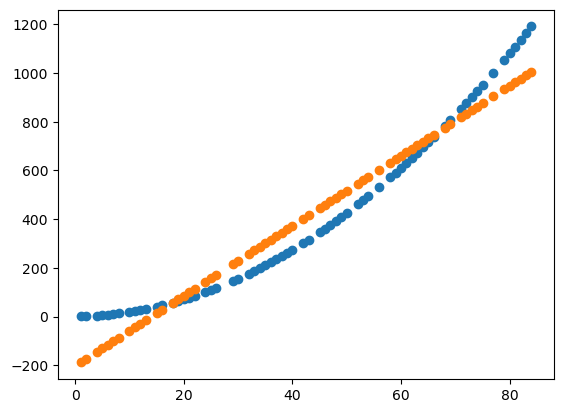

In [14]:
ypred_train=model.predict(update_Xtrain)
plt.scatter(update_Xtrain[:,1],ytrain)
plt.scatter(update_Xtrain[:,1],ypred_train) 

In [15]:
train_score=r2_score(ytrain,ypred_train)

In [16]:
ypred_test=model.predict(update_Xtest)
test_score=r2_score(ytest,ypred_test)
print(f"Test Score :{test_score}")


Test Score :0.9444489642133602


In [17]:
mae=mean_absolute_error(ytest,ypred_test)
rmse=root_mean_squared_error(ytest,ypred_test)
print(f"MAE : {mae}")
print(f"RMSE: {rmse}")

MAE : 69.42352864973896
RMSE: 79.53379394700232


`Bias` : Low

`Variance` : Low 

`Model` : good fit (Generalization : good (the model performs well on unseen data))